In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 📊 DATASET 1: RETAIL PRICING & DEMAND SIGNALS"))

df = pd.read_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\raw\retail_pricing_demand_signals\retail_pricing_demand_100k.csv")

print("Shape:", df.shape)
df.head()

## 📊 DATASET 1: RETAIL PRICING & DEMAND SIGNALS

Shape: (172800, 17)


,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2026-01-01,P1001,Shoes,Nike,AU,mobile,Winter,173.55,112.81,-35.0,35,Buy One Get One,15,1692.15,153,0,133.93
1,2026-01-02,P1001,Shoes,Nike,AU,web,Winter,173.55,173.55,0.0,0,NaN,10,1735.50,185,0,89.29
2,2026-01-03,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,312,0,116.07
3,2026-01-04,P1001,Shoes,Nike,AU,web,Winter,173.55,164.87,-5.0,5,Member Offer,13,2143.31,227,0,116.07
4,2026-01-05,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,247,0,116.07


In [4]:
display(Markdown("### 🔍 Step 1: Data Types & Structure"))
df.info()

### 🔍 Step 1: Data Types & Structure

<class 'pandas.DataFrame'>
RangeIndex: 172800 entries, 0 to 172799
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              172800 non-null  str    
 1   product_id        172800 non-null  str    
 2   category          172800 non-null  str    
 3   brand             172800 non-null  str    
 4   region            172800 non-null  str    
 5   channel           172800 non-null  str    
 6   season            172800 non-null  str    
 7   base_price        172800 non-null  float64
 8   current_price     172800 non-null  float64
 9   price_change_pct  172800 non-null  float64
 10  discount_pct      172800 non-null  int64  
 11  promotion_type    72645 non-null   str    
 12  units_sold        172800 non-null  int64  
 13  revenue           172800 non-null  float64
 14  inventory_level   172800 non-null  int64  
 15  stockout_flag     172800 non-null  int64  
 16  demand_index      172800 non-nu

In [5]:
display(Markdown("### ⚠️ Step 2: Missing Values Check"))
print(df.isnull().sum())

### ⚠️ Step 2: Missing Values Check

date                     0
product_id               0
category                 0
brand                    0
region                   0
channel                  0
season                   0
base_price               0
current_price            0
price_change_pct         0
discount_pct             0
promotion_type      100155
units_sold               0
revenue                  0
inventory_level          0
stockout_flag            0
demand_index             0
dtype: int64


In [6]:
display(Markdown("### 🔁 Step 3: Duplicate Check"))
print("Duplicate rows:", df.duplicated().sum())

### 🔁 Step 3: Duplicate Check

Duplicate rows: 0


In [7]:
display(Markdown("### 📈 Step 4: Summary Statistics"))
df.describe()

### 📈 Step 4: Summary Statistics

,base_price,current_price,price_change_pct,discount_pct,units_sold,revenue,inventory_level,stockout_flag,demand_index
count,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000
mean,221.370656,197.828360,-10.657955,10.657957,14.120735,2757.295723,265.278299,0.001325,117.443514
std,125.659903,118.293731,14.559533,14.559510,8.344558,2410.520529,85.315024,0.036380,33.590506
min,8.550000,4.280000,-50.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,112.302500,97.160000,-20.000000,0.000000,7.000000,856.560000,208.000000,0.000000,95.240000
50%,217.325000,188.960000,0.000000,0.000000,13.000000,2023.890000,265.000000,0.000000,113.640000
75%,326.277500,287.960000,0.000000,20.000000,20.000000,4064.280000,323.000000,0.000000,136.090000
max,449.740000,449.740000,0.000000,50.000000,69.000000,18431.970000,646.000000,1.000000,365.080000


In [8]:
display(Markdown("### ✅ Step 5: Validity Checks"))
print("Negative prices:", (df['current_price'] < 0).sum())
print("Negative units sold:", (df['units_sold'] < 0).sum())
print("Zero/negative inventory:", (df['inventory_level'] <= 0).sum())
print("Stockout flag values:", df['stockout_flag'].unique())
print("Date range:", df['date'].min(), "to", df['date'].max())

### ✅ Step 5: Validity Checks

Negative prices: 0
Negative units sold: 0
Zero/negative inventory: 165
Stockout flag values: [0 1]
Date range: 2026-01-01 to 2026-03-31


### 🎨 Chart 1: Price Distribution

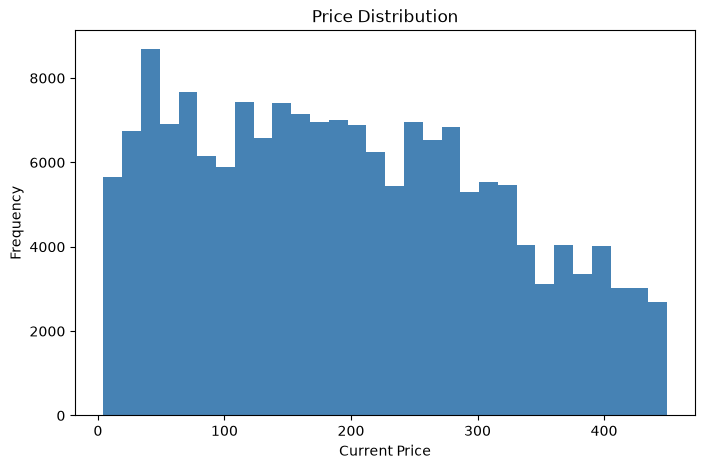

In [10]:
display(Markdown("### 🎨 Chart 1: Price Distribution"))

plt.figure(figsize=(8,5))
plt.hist(df['current_price'], bins=30, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Current Price')
plt.ylabel('Frequency')
plt.show()

### 🎨 Chart 2: Total Units Sold by Category

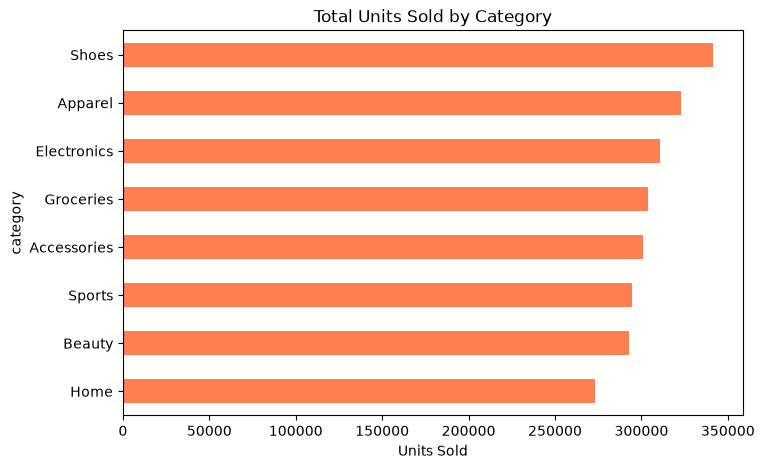

In [11]:
display(Markdown("### 🎨 Chart 2: Total Units Sold by Category"))

plt.figure(figsize=(8,5))
df.groupby('category')['units_sold'].sum().sort_values().plot(kind='barh', color='coral')
plt.title('Total Units Sold by Category')
plt.xlabel('Units Sold')
plt.show()

### 🎨 Chart 3: Discount % vs Units Sold

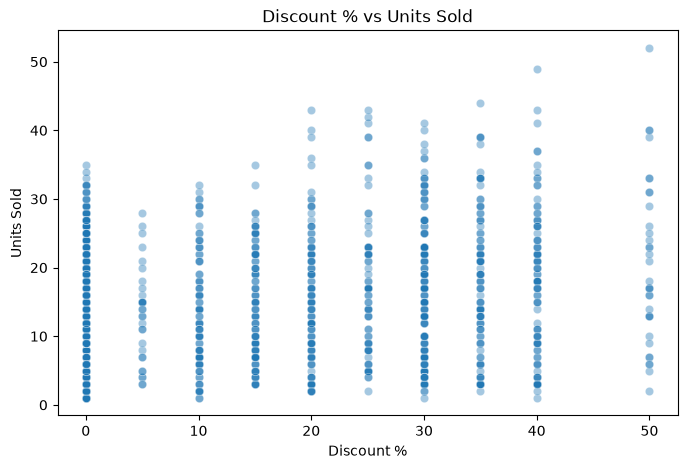

In [12]:
display(Markdown("### 🎨 Chart 3: Discount % vs Units Sold"))

plt.figure(figsize=(8,5))
sns.scatterplot(data=df.sample(2000), x='discount_pct', y='units_sold', alpha=0.4)
plt.title('Discount % vs Units Sold')
plt.xlabel('Discount %')
plt.ylabel('Units Sold')
plt.show()

### 🎨 Chart 4: Total Revenue by Region

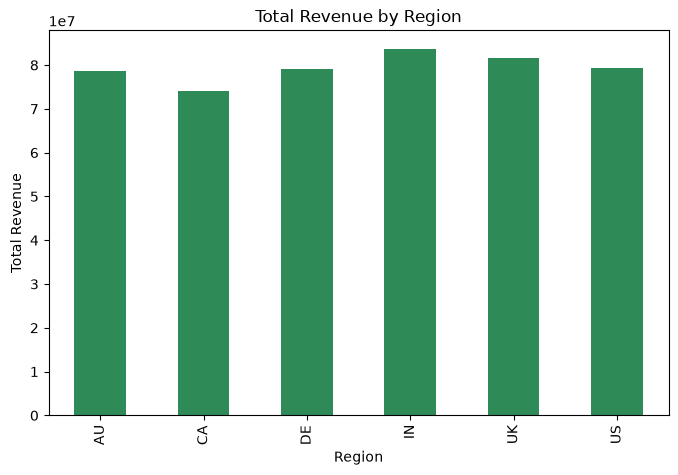

In [13]:
display(Markdown("### 🎨 Chart 4: Total Revenue by Region"))

plt.figure(figsize=(8,5))
df.groupby('region')['revenue'].sum().plot(kind='bar', color='seagreen')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.show()

### 🎨 Step 6: Visual EDA

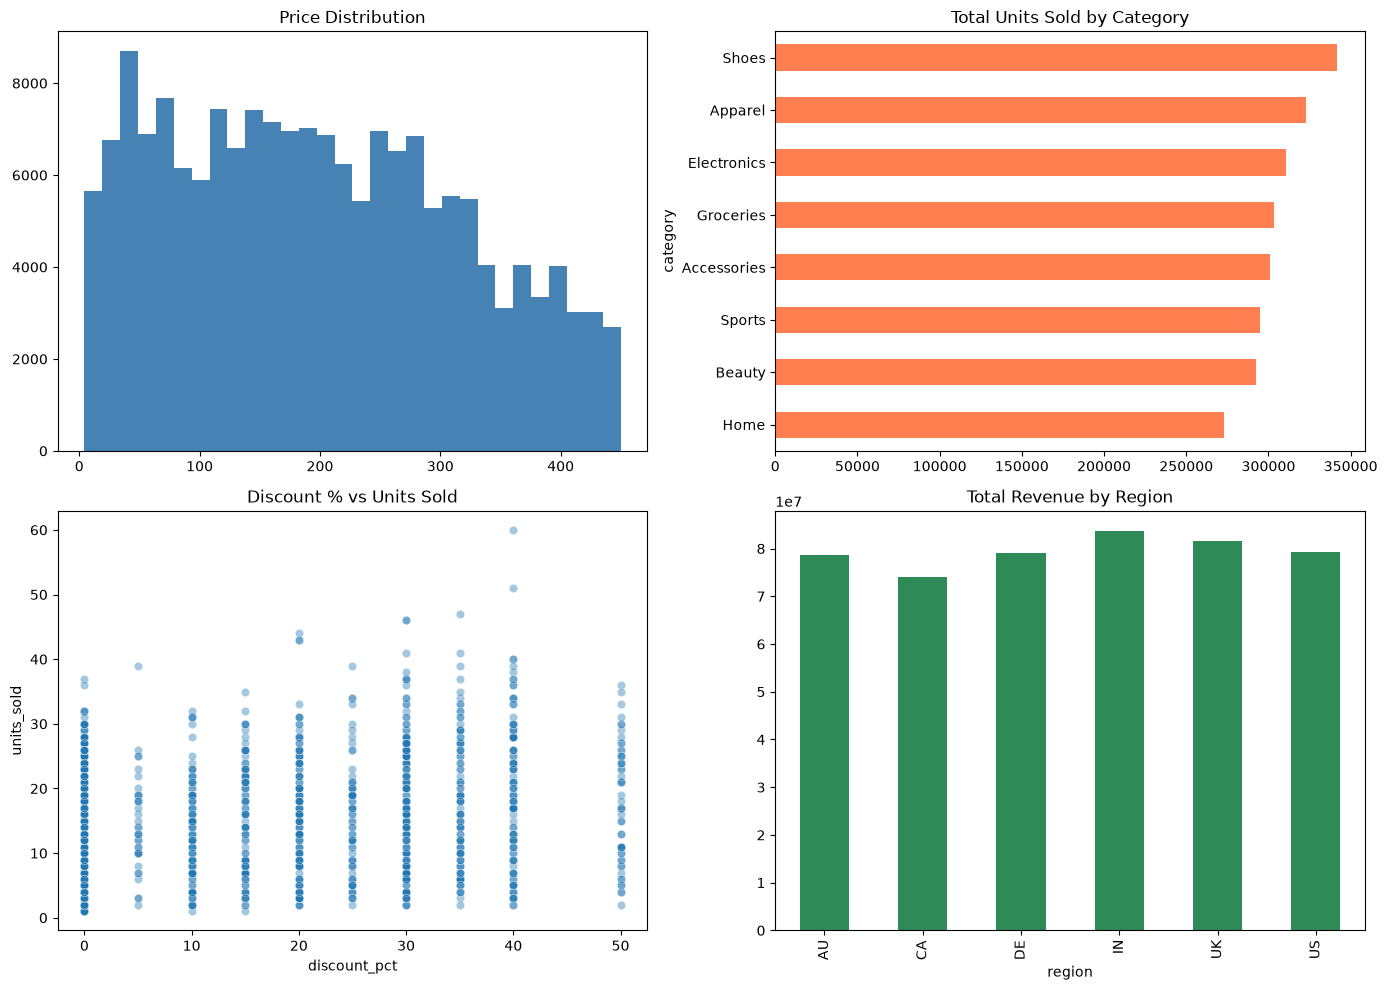

In [14]:
display(Markdown("### 🎨 Step 6: Visual EDA"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['current_price'], bins=30, color='steelblue')
axes[0,0].set_title('Price Distribution')

df.groupby('category')['units_sold'].sum().sort_values().plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Total Units Sold by Category')

sns.scatterplot(data=df.sample(2000), x='discount_pct', y='units_sold', alpha=0.4, ax=axes[1,0])
axes[1,0].set_title('Discount % vs Units Sold')

df.groupby('region')['revenue'].sum().plot(kind='bar', ax=axes[1,1], color='seagreen')
axes[1,1].set_title('Total Revenue by Region')

plt.tight_layout()
plt.show()

In [15]:
display(Markdown("### 🧹 Step 7: Data Cleaning"))

df['promotion_type'] = df['promotion_type'].fillna('No Promotion')
df['date'] = pd.to_datetime(df['date'])

print("Missing values after cleanup:")
print(df.isnull().sum())
print("\nDate column type:", df['date'].dtype)

### 🧹 Step 7: Data Cleaning

Missing values after cleanup:
date                0
product_id          0
category            0
brand               0
region              0
channel             0
season              0
base_price          0
current_price       0
price_change_pct    0
discount_pct        0
promotion_type      0
units_sold          0
revenue             0
inventory_level     0
stockout_flag       0
demand_index        0
dtype: int64

Date column type: datetime64[us]


In [16]:
display(Markdown("### 💾 Step 8: Save Cleaned Dataset"))

df.to_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\retail_pricing_demand_clean.csv", index=False)

print("Saved successfully!")
print("Final shape:", df.shape)

### 💾 Step 8: Save Cleaned Dataset

Saved successfully!
Final shape: (172800, 17)
